# 0. 환경설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations, product
import seaborn as sns
from scipy import stats
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 깨짐 방지 (Windows)
plt.rcParams['axes.unicode_minus'] = False

# 1. 개요

## 1. 기본정보

In [2]:
# 1-1 CSV 파일 불러오기

df = pd.read_csv("../../CSV_files/courses.csv")
df.head()

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


In [3]:
# 1-2 정보

df.info()

# ? 22행짜리 아주 작은 표 -> assessments.csv처럼 '학생 단위'가 아니라 '모듈-학기 단위'의 정의표로 보임
# ? code_module, code_presentation 조합이 식별자 역할을 하는가?

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   code_module                 22 non-null     str  
 1   code_presentation           22 non-null     str  
 2   module_presentation_length  22 non-null     int64
dtypes: int64(1), str(2)
memory usage: 660.0 bytes


In [4]:
# 1-3 기술통계
# code_module, code_presentation은 코드값이라 기술통계 대상에서 제외, module_presentation_length만 의미있음

df.describe()

# module_presentation_length(운영 기간, 일 단위) 평균 255.5일, 표준편차 13.65일
# 최소 234일 ~ 최대 269일로 폭이 35일 정도

,module_presentation_length
count,22.000000
mean,255.545455
std,13.654677
min,234.000000
25%,241.000000
50%,261.500000
75%,268.000000
max,269.000000


In [5]:
# 1-4 결측치 위치 조회

df.isna().sum()

# ! 결측치(NaN)는 전혀 없음
# 다만 아래 2-4에서 확인하듯, NaN은 없어도 '행 자체가 존재하지 않는' 조합이 있음 -> 이것도 일종의 구조적 결측

code_module                   0
code_presentation             0
module_presentation_length    0
dtype: int64

## 2. 속성별 정보

In [6]:
# 2-1 속성 종류

df.columns

Index(['code_module', 'code_presentation', 'module_presentation_length'], dtype='str')

In [7]:
# 2-2 속성 데이터 타입

df.dtypes

code_module                     str
code_presentation               str
module_presentation_length    int64
dtype: object

In [8]:
# 2-3 고유값 개수

df.nunique()

# code_module                    7   -> 값이 적음 -> 범주형
# code_presentation               4   -> 값이 적음 -> 범주형
# module_presentation_length      7   -> code_module과 우연히 개수는 같지만, 실제로는 22개 행에서 반복되는 '기간(일수)'이라 연속형 수치로 봐야 함

code_module                   7
code_presentation             4
module_presentation_length    7
dtype: int64

In [9]:
# 2-4 식별자(복합키) 무결성 체크
# 이 표는 '모듈-학기' 단위 1행이 정상이므로 (code_module, code_presentation) 조합이 유일해야 함

dup = df.duplicated(subset=['code_module', 'code_presentation'])
print('중복 조합 개수:', dup.sum())

# 실제로 존재 가능한 조합(7개 모듈 x 4개 학기) 대비 실제 존재하는 조합 수 비교
modules = sorted(df['code_module'].unique())
presentations = sorted(df['code_presentation'].unique())
full_combo = set(product(modules, presentations))
actual_combo = set(zip(df['code_module'], df['code_presentation']))
missing_combo = full_combo - actual_combo

print(f'가능한 조합: {len(full_combo)}개, 실제 존재하는 조합: {len(actual_combo)}개, 누락된 조합: {len(missing_combo)}개')
sorted(missing_combo)

중복 조합 개수: 0
가능한 조합: 28개, 실제 존재하는 조합: 22개, 누락된 조합: 6개


[('AAA', '2013B'),
 ('AAA', '2014B'),
 ('CCC', '2013B'),
 ('CCC', '2013J'),
 ('EEE', '2013B'),
 ('GGG', '2013B')]

### courses.csv 속성 정리

| 컬럼명 | 타입 | 설명 | 값 예시 / 범위 | 결측치 |
|---|---|---|---|---|
| code_module | object | 모듈(과목) 식별 코드 | AAA, BBB, CCC, DDD, EEE, FFF, GGG (7종) | 0 |
| code_presentation | object | 개강 학기 코드. 연도 + B(2월 개강)/J(10월 개강) | 2013B, 2013J, 2014B, 2014J (4종) | 0 |
| module_presentation_length | int64 | 해당 모듈-학기의 총 운영 기간(일) | 234 ~ 269일 | 0 |

**행/열 구조**: 22 rows × 3 columns
(가능한 조합 28개 중 22개만 실제로 개설됨 -> 6개 조합은 애초에 개설되지 않음)

**참고**
- (code_module, code_presentation) 조합이 이 표의 실질적인 행 식별자
- NaN 형태의 결측치는 없지만, 개설되지 않은 모듈-학기 조합(행 자체의 부재)이 6건 존재
- module_presentation_length는 숫자지만 사실상 '2월 개강(B)이냐 10월 개강(J)이냐'에 따라 크게 갈리는 값으로 보임(2장에서 확인)

# 2. 그래프 및 구조

## 1. 범주형 그래프

In [10]:
# 0. 범주형/수치형 구분

cat_cols = ['code_module', 'code_presentation']
num_cols = ['module_presentation_length']
print('범주형:', cat_cols)
print('수치형:', num_cols)

범주형: ['code_module', 'code_presentation']
수치형: ['module_presentation_length']


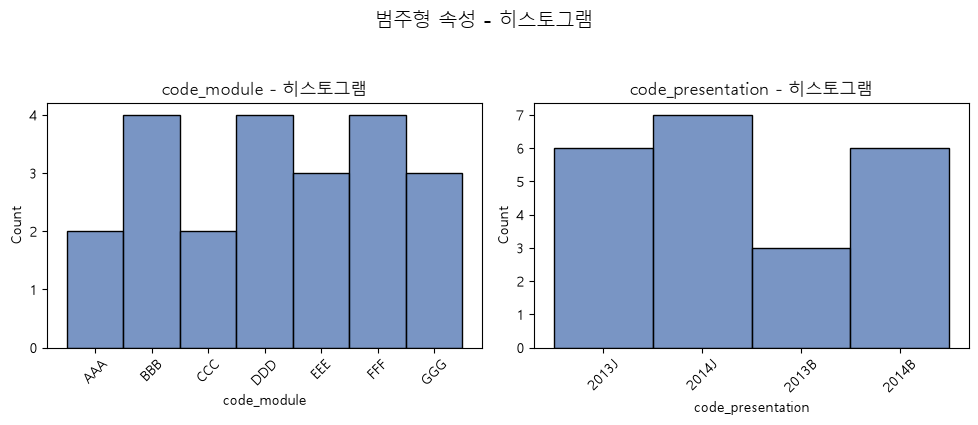

In [11]:
# 1-1 히스토그램(countplot)

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))

for ax, col in zip(axes, cat_cols):
    sns.histplot(data=df, x=col, discrete=True, color='#4C72B0', ax=ax)
    ax.set_title(f'{col} - 히스토그램')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('범주형 속성 - 히스토그램', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# ? code_module별 개설 횟수가 2~4회로 다른 이유는? (7개 모듈이 4개 학기에 고르게 개설되지 않음)

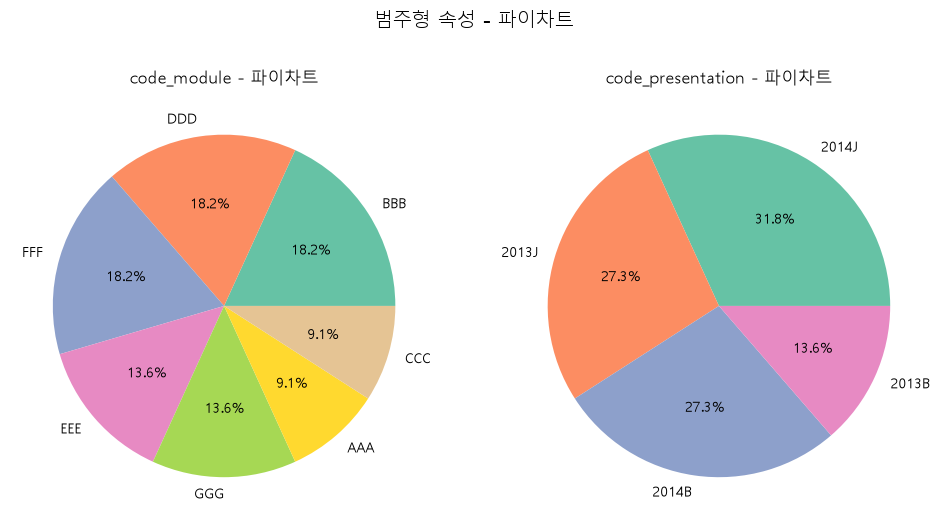

In [12]:
# 1-2 파이차트

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 5))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
           colors=sns.color_palette('Set2', len(counts)))
    ax.set_title(f'{col} - 파이차트')

fig.suptitle('범주형 속성 - 파이차트', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

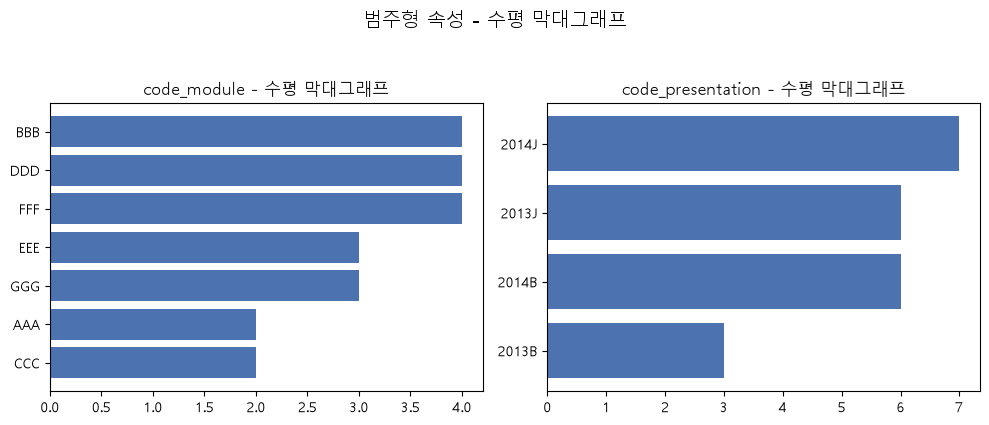

In [13]:
# 1-3 수평 막대그래프

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.barh(counts.index, counts.values, color='#4C72B0')
    ax.invert_yaxis()
    ax.set_title(f'{col} - 수평 막대그래프')

fig.suptitle('범주형 속성 - 수평 막대그래프', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# ! code_presentation은 2013B(3개) < 2013J/2014B(6개) < 2014J(7개) 순으로 개설된 모듈 수가 다름

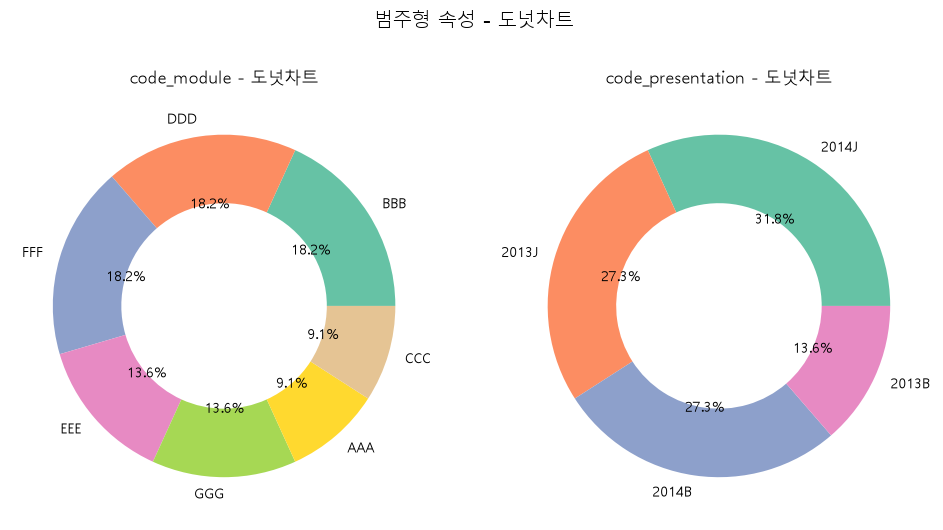

In [14]:
# 1-4 도넛차트

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 5))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
           colors=sns.color_palette('Set2', len(counts)),
           wedgeprops={'width': 0.4})
    ax.set_title(f'{col} - 도넛차트')

fig.suptitle('범주형 속성 - 도넛차트', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

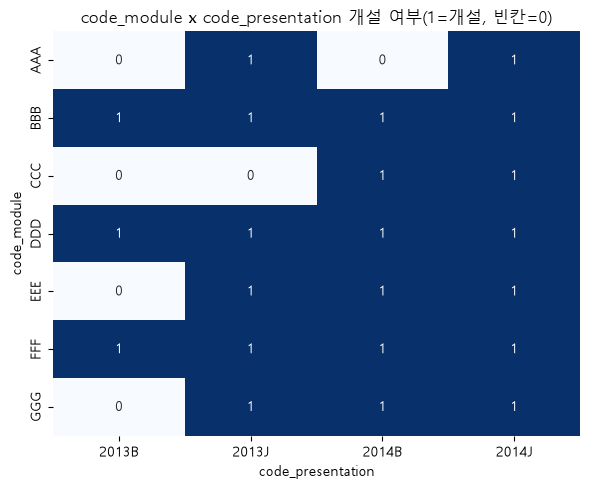

code_presentation,2013B,2013J,2014B,2014J
code_module,,,,
AAA,0,1,0,1
BBB,1,1,1,1
CCC,0,0,1,1
DDD,1,1,1,1
EEE,0,1,1,1
FFF,1,1,1,1
GGG,0,1,1,1


In [15]:
# 1-5 히트맵(범주형끼리 관계) - 개설 여부(0/1) 확인
# Q 질문 도출: 어떤 모듈-학기 조합이 비어있는가? (2-4에서 확인한 6개 누락 조합과 일치하는지 시각적으로 재확인)

cross = pd.crosstab(df['code_module'], df['code_presentation'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cross, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title('code_module x code_presentation 개설 여부(1=개설, 빈칸=0)')
plt.tight_layout()
plt.show()

cross

# ! AAA는 2013B/2014B(2월 개강)에 한 번도 개설되지 않음
# ! CCC는 2013년도(B/J 모두)에 개설되지 않고 2014년부터 등장함

## 2. 수치형 그래프

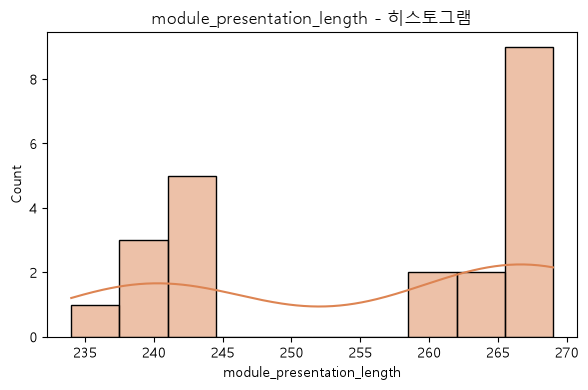

In [16]:
# 2-1 히스토그램(+KDE)

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df, x='module_presentation_length', bins=10, kde=True, color='#DD8452', ax=ax)
ax.set_title('module_presentation_length - 히스토그램')
plt.tight_layout()
plt.show()

# ? 240일 근처와 265일 근처, 두 군데에 봉우리가 보이는 이유는? (이중봉 -> 2절에서 확인할 B/J 학기 차이가 원인으로 추정)

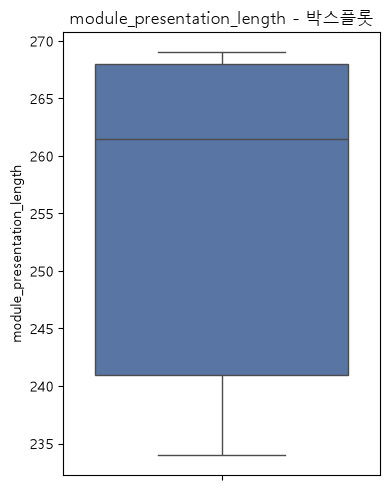

In [17]:
# 2-2 박스플롯

fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(data=df, y='module_presentation_length', color='#4C72B0', ax=ax)
ax.set_title('module_presentation_length - 박스플롯')
plt.tight_layout()
plt.show()

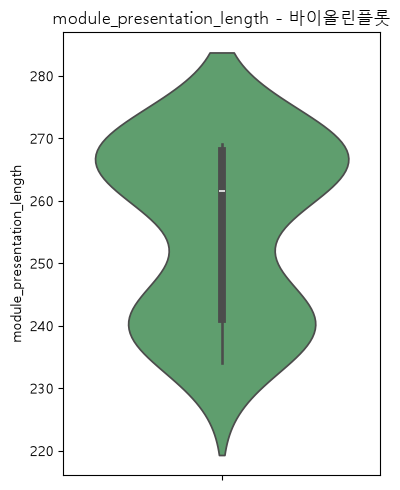

In [18]:
# 2-3 바이올린플롯

fig, ax = plt.subplots(figsize=(4, 5))
sns.violinplot(data=df, y='module_presentation_length', color='#55A868', ax=ax)
ax.set_title('module_presentation_length - 바이올린플롯')
plt.tight_layout()
plt.show()

# ! 바이올린 모양이 허리 부분이 잘록한 두 덩어리 형태 -> 이중봉 분포가 더 뚜렷하게 보임

In [19]:
# 2-4 왜도/첨도 및 이상치(IQR)

col = 'module_presentation_length'
print(f"[{col}] skew={df[col].skew():.3f}, kurt={df[col].kurt():.3f}")

q1, q3 = df[col].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f'이상치 개수: {len(outliers)} (기준: {lower:.1f} ~ {upper:.1f})')

# 첨도(kurt)가 음수로 크게 나오는 것은 정규분포보다 납작하고 두 덩어리로 갈라진 분포이기 때문(이중봉과 일치)
# 이상치는 없음 -> 모든 값이 234~269일 사이의 '정상적인' 두 그룹(짧은 학기/긴 학기) 중 하나에 속함

[module_presentation_length] skew=-0.327, kurt=-1.877
이상치 개수: 0 (기준: 200.5 ~ 308.5)


## 3. 범주형과 수치형 종합 그래프

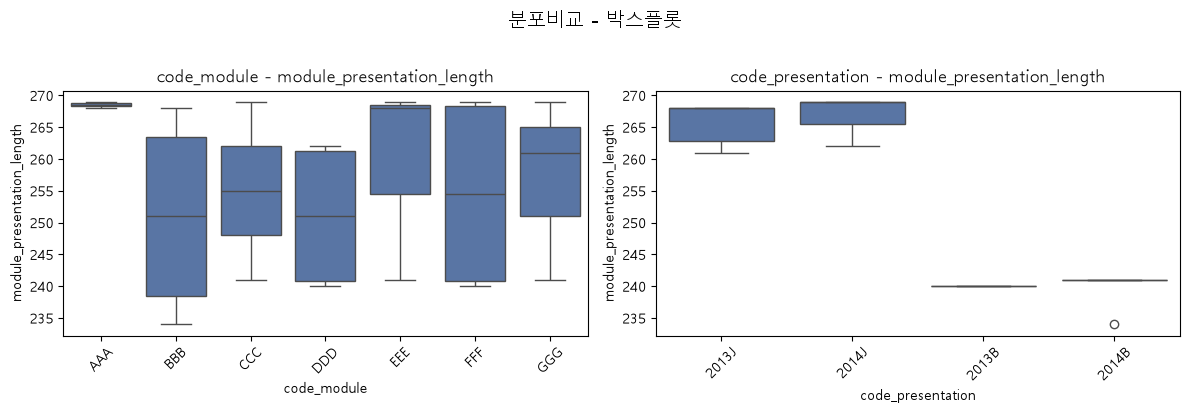

In [20]:
# 3-1 분포비교 - 박스플롯

fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 4))

for ax, cat_col in zip(axes, cat_cols):
    sns.boxplot(data=df, x=cat_col, y='module_presentation_length', color='#4C72B0', ax=ax)
    ax.set_title(f'{cat_col} - module_presentation_length')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('분포비교 - 박스플롯', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ! code_presentation 기준으로 보면 2013B/2014B(약 234~241일)과 2013J/2014J(약 261~269일)가 뚜렷하게 나뉨

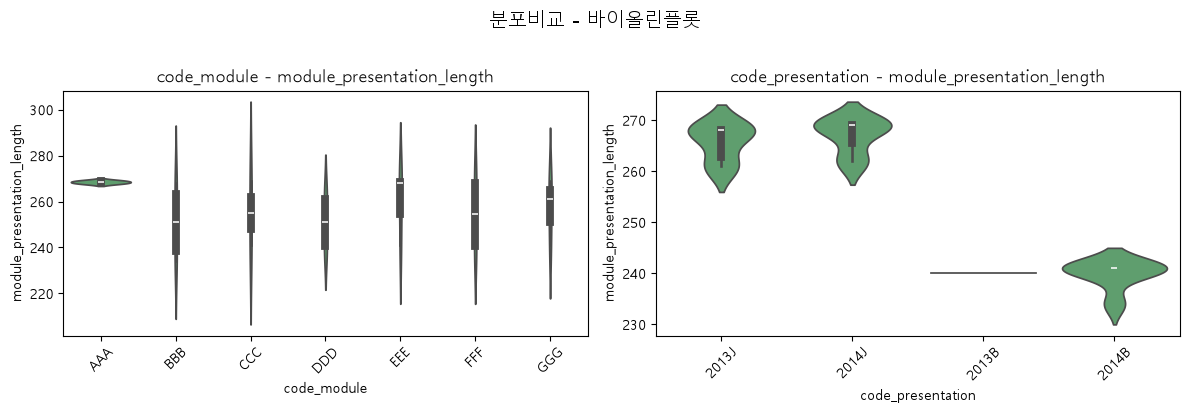

In [21]:
# 3-2 분포비교 - 바이올린플롯

fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 4))

for ax, cat_col in zip(axes, cat_cols):
    sns.violinplot(data=df, x=cat_col, y='module_presentation_length', color='#55A868', ax=ax)
    ax.set_title(f'{cat_col} - module_presentation_length')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('분포비교 - 바이올린플롯', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

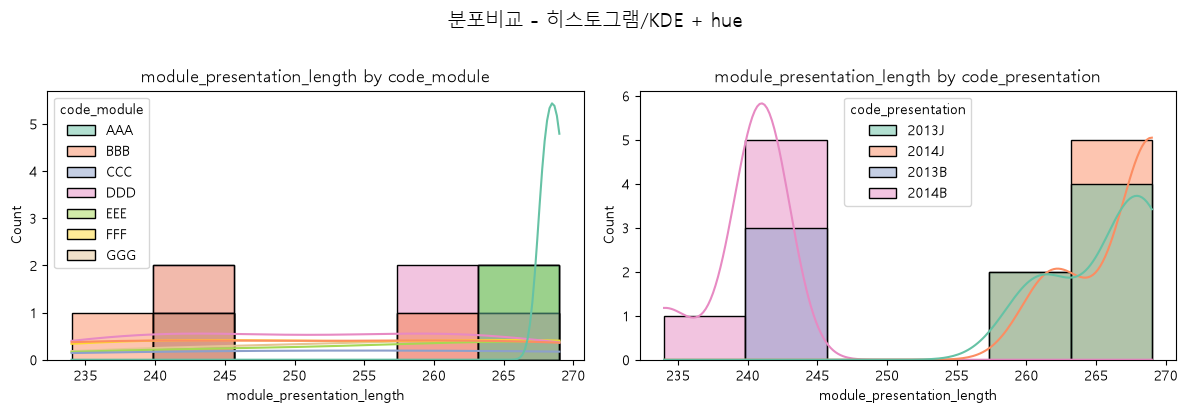

In [22]:
# 3-3 분포비교 - 히스토그램(+KDE) + hue

fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 4))

for ax, cat_col in zip(axes, cat_cols):
    sns.histplot(data=df, x='module_presentation_length', hue=cat_col, kde=True, palette='Set2', ax=ax)
    ax.set_title(f'module_presentation_length by {cat_col}')

fig.suptitle('분포비교 - 히스토그램/KDE + hue', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

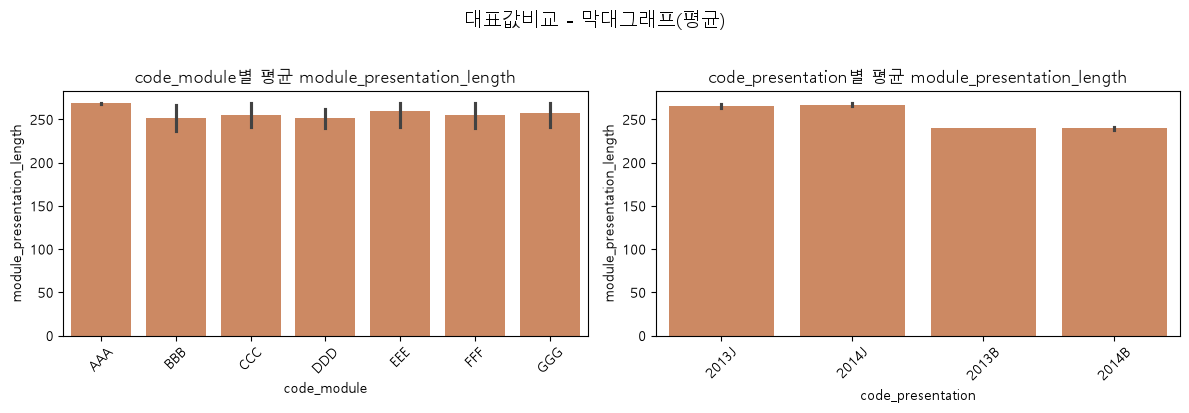

In [23]:
# 3-4 대표값 비교 - 막대그래프(평균)

fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 4))

for ax, cat_col in zip(axes, cat_cols):
    sns.barplot(data=df, x=cat_col, y='module_presentation_length', color='#DD8452', ax=ax)
    ax.set_title(f'{cat_col}별 평균 module_presentation_length')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('대표값비교 - 막대그래프(평균)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

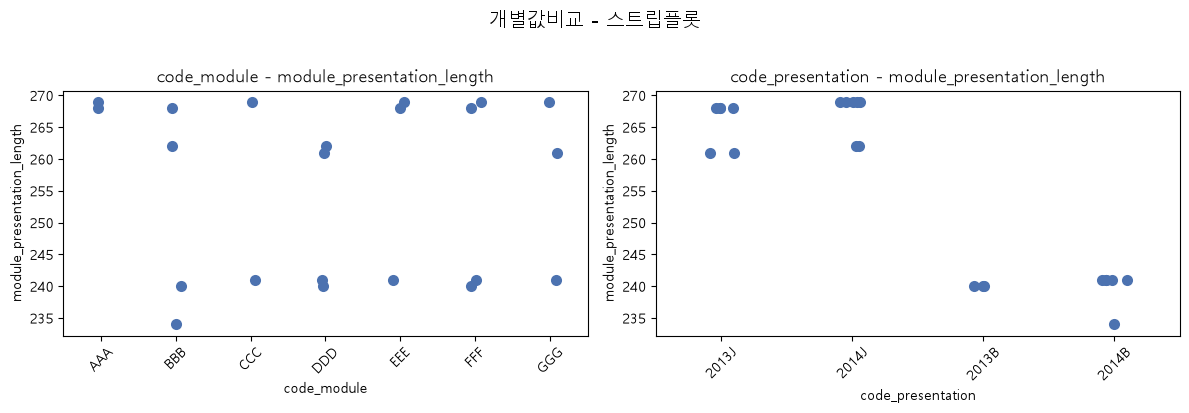

In [24]:
# 3-5 개별값 비교 - 스트립플롯
# 전체 22건뿐이라 샘플링 없이 그대로 사용

fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 4))

for ax, cat_col in zip(axes, cat_cols):
    sns.stripplot(data=df, x=cat_col, y='module_presentation_length', color='#4C72B0', size=8, ax=ax)
    ax.set_title(f'{cat_col} - module_presentation_length')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('개별값비교 - 스트립플롯', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

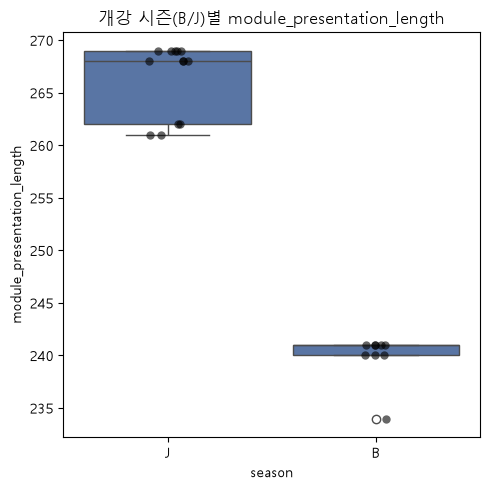

,count,mean,median,std
season,,,,
B,9,239.888889,241.0,2.260777
J,13,266.384615,268.0,3.428762


In [25]:
# 3-6 파생변수 확인 - 학기유형(B/J)별 비교
# code_presentation 끝 글자(B=2월 개강, J=10월 개강)를 파생시켜 비교

df['season'] = df['code_presentation'].str[-1]

fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=df, x='season', y='module_presentation_length', color='#4C72B0', ax=ax)
sns.stripplot(data=df, x='season', y='module_presentation_length', color='black', size=6, alpha=0.6, ax=ax)
ax.set_title('개강 시즌(B/J)별 module_presentation_length')
plt.tight_layout()
plt.show()

df.groupby('season')['module_presentation_length'].agg(['count', 'mean', 'median', 'std'])

# ! B(2월 개강)는 234~241일, J(10월 개강)는 261~269일로 겹치는 구간이 전혀 없음

# 3. 통계 검정이 필요한지

## 핵심 원칙
> **검정은 "질문"이 있을 때만 한다.**

앞선 두 파일(assessments.csv, studentAssessment.csv)과 달리, courses.csv는 행이 22개뿐인
아주 작은 정의표다. 하지만 3-6에서 파생시킨 `season`(B/J)이라는 **명확한 두 집단**이 조인 없이도
이미 존재하고, 박스플롯에서 두 집단이 전혀 겹치지 않는 것을 눈으로 확인했다.
"개강 시즌(B/J)에 따라 강좌 운영 기간이 실제로 다른가?"라는 질문이 성립하므로 검정을 해볼 근거가
충분하다.

In [26]:
# season(B) vs season(J) 그룹간 module_presentation_length 비교

g_b = df[df['season'] == 'B']['module_presentation_length']
g_j = df[df['season'] == 'J']['module_presentation_length']

print('B 그룹 n=', len(g_b), ' J 그룹 n=', len(g_j))

# 정규성 참고 확인 (표본이 매우 작아 Shapiro 결과의 신뢰도 자체가 낮다는 점을 감안)
print('Shapiro B:', stats.shapiro(g_b))
print('Shapiro J:', stats.shapiro(g_j))

# 표본이 작고 정규성이 불확실하므로 비모수 검정(Mann-Whitney U)을 우선 사용
u_stat, u_p = stats.mannwhitneyu(g_b, g_j, alternative='two-sided')
print(f'Mann-Whitney U: stat={u_stat:.1f}, p={u_p:.4g}')

# 참고용으로 등분산을 가정하지 않는 Welch's t-test도 함께 확인
t_stat, t_p = stats.ttest_ind(g_b, g_j, equal_var=False)
print(f"Welch's t-test: stat={t_stat:.2f}, p={t_p:.4g}")

print('B 평균:', round(g_b.mean(), 1), ' J 평균:', round(g_j.mean(), 1))

B 그룹 n= 9  J 그룹 n= 13
Shapiro B: ShapiroResult(statistic=np.float64(0.5490635980157546), pvalue=np.float64(2.41340320582421e-05))
Shapiro J: ShapiroResult(statistic=np.float64(0.7003504813777254), pvalue=np.float64(0.000559405544422149))
Mann-Whitney U: stat=0.0, p=8.29e-05
Welch's t-test: stat=-21.84, p=2.045e-15
B 평균: 239.9  J 평균: 266.4


## 결과 해석
- 표본이 각각 9건(B), 13건(J)으로 매우 작아 Shapiro-Wilk 결과 자체의 신뢰도는 낮지만, 두 검정(비모수/모수)
  모두 p<0.001 수준으로 뚜렷하게 유의하다.
- 두 그룹의 값 범위가 전혀 겹치지 않는다(B: 234~241일, J: 261~269일)는 사실 자체가 이미 강력한 근거이며,
  검정 결과는 이를 통계적으로 재확인해줄 뿐이다.
- 앞의 두 파일에서 본 사례와 달리, 여기서는 표본 크기 효과로 인한 '과도하게 유의한' 결과를 걱정할 필요가
  없다 — 표본이 작은데도 유의하다는 것은 그만큼 차이가 명확하다는 뜻이다.
- 결론: **개강 시즌(B/J)은 강좌 운영 기간을 사실상 결정짓는 변수**이며, 이후 다른 파일과의 조인 분석에서
  `code_presentation`을 볼 때는 연도보다 이 B/J 구분이 더 본질적인 축일 수 있다.

# 4. 단독으로 확인할 수 있는 이탈률과 연관된 것들(검증은 조인)

## Q1. 운영 기간이 긴 학기(J)가 짧은 학기(B)보다 이탈에 유리할까 불리할까?

### 과정

In [27]:
# 근거 : 3-6 파생변수 확인 / 3장 통계 검정 결과

df.groupby('season')['module_presentation_length'].agg(['count', 'mean', 'min', 'max'])

,count,mean,min,max
season,,,,
B,9,239.888889,234,241
J,13,266.384615,261,269


### 설명

J(10월 개강) 학기는 평균 266일, B(2월 개강) 학기는 평균 240일로 약 26일(한 달 가까이) 차이가 난다.
이 차이가 이탈에 어떤 영향을 주는지는 두 가지 상반된 가설이 모두 가능하다: ①길수록 학습 부담과
지치는 기간이 늘어 이탈이 더 클 것이다, ②길수록 페이스가 여유로워 이탈이 오히려 줄어들 것이다.
courses.csv는 기간(일수)만 담고 있을 뿐 학생 개개인의 이탈 여부가 없어 이 파일만으로는 어느 쪽인지
판단할 수 없다.

## Q2. 특정 모듈이 특정 학기유형에만 개설되는 구조가 이탈률 비교를 왜곡할 수 있을까?

### 과정

In [28]:
# 근거 : 2-4 식별자 무결성 체크 / 1-5 히트맵

cross = pd.crosstab(df['code_module'], df['code_presentation'])
cross

code_presentation,2013B,2013J,2014B,2014J
code_module,,,,
AAA,0,1,0,1
BBB,1,1,1,1
CCC,0,0,1,1
DDD,1,1,1,1
EEE,0,1,1,1
FFF,1,1,1,1
GGG,0,1,1,1


### 설명

AAA는 2013B/2014B(2월 개강)에 한 번도 개설되지 않았고, CCC는 2013년도(B/J 모두)에 개설되지 않았다.
즉 AAA 수강생은 항상 긴 학기(J)만, CCC 수강생은 항상 2014년도 학기만 경험한다. 이 상태에서 단순히
"code_module별 이탈률"을 비교하면 실제로는 모듈 자체의 효과가 아니라 '그 모듈이 우연히 어떤 학기
유형에 개설됐는가'라는 교란 요인이 함께 섞여 나올 위험이 있다.

## Q3. 같은 모듈이라도 학기마다 운영 기간 변동이 큰 경우가 있을까?

### 과정

In [29]:
# 근거 : 3-1 분포비교 박스플롯

df.groupby('code_module')['module_presentation_length'].agg(['mean', 'std', 'count']).sort_values('std', ascending=False)

,mean,std,count
code_module,,,
CCC,255.000000,19.798990,2
BBB,251.000000,16.532796,4
FFF,254.500000,16.176114,4
EEE,259.333333,15.885003,3
GGG,257.000000,14.422205,3
DDD,251.000000,12.138094,4
AAA,268.500000,0.707107,2


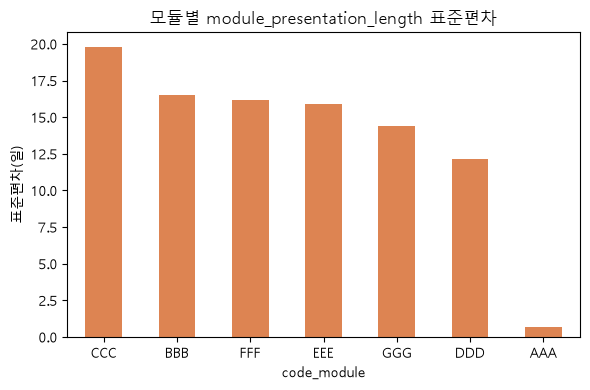

In [30]:
# Q3 보강: 모듈별 module_presentation_length 표준편차 시각화

std_by_module = df.groupby('code_module')['module_presentation_length'].std().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
std_by_module.plot(kind='bar', color='#DD8452', ax=ax)
ax.set_title('모듈별 module_presentation_length 표준편차')
ax.set_ylabel('표준편차(일)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ! BBB/DDD/FFF처럼 4개 학기 모두 개설된 모듈일수록 표준편차가 크고, AAA처럼 특정 시즌에만 개설된 모듈은 0에 가까움

### 설명

BBB, DDD, FFF처럼 4개 학기 모두 개설된 모듈은 표준편차가 12~16일로 꽤 크다 — 이는 결국 같은 모듈이라도
B/J가 섞여 있기 때문이다(Q1의 B/J 차이가 모듈 내부에서도 그대로 나타남). 반대로 AAA는 표준편차가
0.7일로 거의 일정한데, 이는 AAA가 항상 J 학기에만 개설되기 때문이다(Q2와 같은 맥락). 즉 '모듈별
변동성'으로 보이는 것의 상당 부분이 사실은 '그 모듈이 어떤 학기 유형에 개설됐는가'로 설명된다.

## Q4. courses.csv만으로 이탈률 자체를 계산할 수 없는 이유

### 과정

In [31]:
print('행 수:', len(df), '/ 컬럼 수:', df.shape[1])
df.columns.tolist()

행 수: 22 / 컬럼 수: 4


['code_module', 'code_presentation', 'module_presentation_length', 'season']

### 설명

courses.csv에는 학생 단위 정보(학생 수, 이탈 여부, 성적 등)가 전혀 없다. 22개 행 각각은
'모듈-학기'라는 하나의 강좌 운영 단위를 나타낼 뿐, 그 강좌에 학생이 몇 명 있었는지도 이 파일만으로는
알 수 없다. 따라서 이 파일은 이탈률을 직접 계산하는 데 쓰이는 파일이 아니라, 다른 학생 단위 파일들의
결과를 해석할 때 배경이 되는 '기준(reference) 테이블'로 봐야 한다.

# 5. 다른 CSV 파일과 연관지어야 확인할 수 있는 것들

## 질문

- `code_module`, `code_presentation`을 `studentRegistration.csv`와 조인하면 강좌별 실제 등록 인원과
  이탈(Withdrawn) 인원·비율을 계산할 수 있다. 이를 `module_presentation_length`, `season`(B/J)과
  연결하면 Q1(운영 기간과 이탈의 방향성)을 실제로 검증할 수 있다.
- `studentInfo.csv`와 조인하면 `final_result`(Withdrawn/Fail/Pass/Distinction) 분포가 B 학기와 J
  학기 사이에 다른지 확인할 수 있다.
- `assessments.csv`와 조인해 `module_presentation_length` 대비 평가 개수(평가 밀도 = 평가 수 ÷
  운영 기간)를 계산하면, 기간이 길다고 해서 실제로 여유로운 일정인지(평가 밀도가 낮은지) 확인할 수
  있다 — 단순히 '기간이 기니까 여유롭다'는 가정이 맞는지 검증하는 질문이다.
- `studentVle.csv`와 조인하면 운영 기간이 다른 강좌 간에 학생들의 총 학습활동(클릭 수)이나 학기 초반
  대비 후반 활동 감소 패턴이 다른지 확인할 수 있다.
- Q2에서 제기한 교란 문제(모듈 효과 vs 학기유형 효과)를 풀려면, 위 조인들에서 `code_module`과
  `season`(B/J)을 함께 통제해 비교해야 한다.
- 이 파일에서 이탈과 직접 무관해 보이는 속성은 없다 — 다만 단독으로는 학생 수준 지표가 전혀 없어,
  항상 다른 파일과 결합했을 때에만 이탈 관련 질문에 답할 수 있다.